In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../data/ethiopia.csv')

In [6]:
df["Country"] = "Ethiopia"

In [7]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

In [8]:
df["Month"] = df["Date"].dt.month

In [9]:
df = df.replace(-999, np.nan)

In [10]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   YEAR         4108 non-null   int64         
 1   DOY          4108 non-null   int64         
 2   T2M          4108 non-null   float64       
 3   T2M_MAX      4108 non-null   float64       
 4   T2M_MIN      4108 non-null   float64       
 5   T2M_RANGE    4108 non-null   float64       
 6   PRECTOTCORR  4108 non-null   float64       
 7   RH2M         4108 non-null   float64       
 8   WS2M         4108 non-null   float64       
 9   WS2M_MAX     4108 non-null   float64       
 10  PS           4108 non-null   float64       
 11  QV2M         4108 non-null   float64       
 12  Country      4108 non-null   str           
 13  Date         4108 non-null   datetime64[us]
 14  Month        4108 non-null   int32         
dtypes: datetime64[us](1), float64(10), int32(1), int64(2), str(1)
memo

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

In [11]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

In [12]:
df.duplicated().sum()
df = df.drop_duplicates()

In [13]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


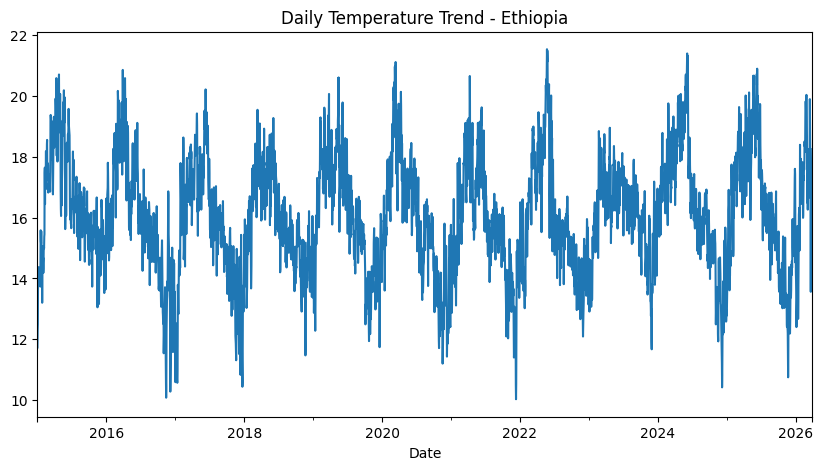

In [14]:
df.groupby("Date")["T2M"].mean().plot(figsize=(10,5))
plt.title("Daily Temperature Trend - Ethiopia")
plt.show()

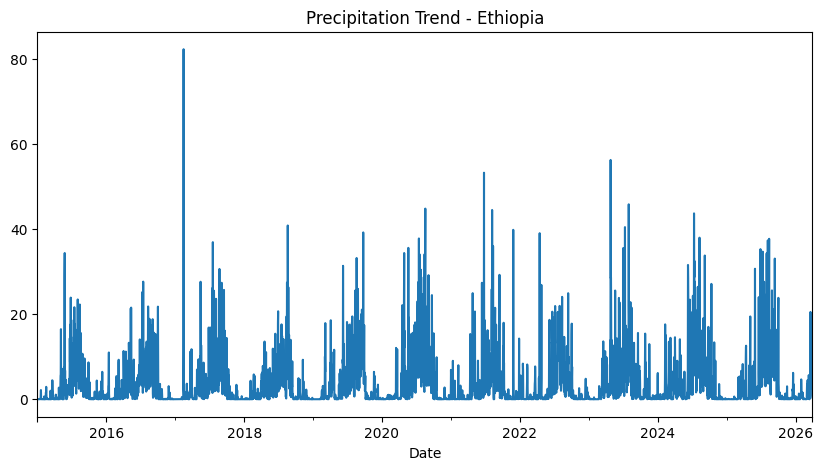

In [15]:
df.groupby("Date")["PRECTOTCORR"].sum().plot(figsize=(10,5))
plt.title("Precipitation Trend - Ethiopia")
plt.show()

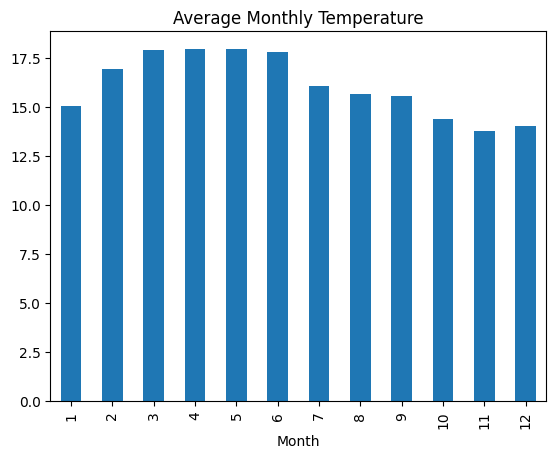

In [16]:
df.groupby("Month")["T2M"].mean().plot(kind="bar")
plt.title("Average Monthly Temperature")
plt.show()

In [17]:
df[["T2M","PRECTOTCORR","RH2M","WS2M"]].corr()

,T2M,PRECTOTCORR,RH2M,WS2M
T2M,1.000000,0.009186,-0.194146,-0.069825
PRECTOTCORR,0.009186,1.000000,0.501347,-0.390109
RH2M,-0.194146,0.501347,1.000000,-0.444068
WS2M,-0.069825,-0.390109,-0.444068,1.000000


In [18]:
from scipy import stats

z = np.abs(stats.zscore(df[["T2M","PRECTOTCORR","RH2M","WS2M"]].dropna()))
print((z > 3).sum())

114


In [26]:
import pandas as pd

ethiopia = pd.read_csv("../data/ethiopia.csv")
kenya = pd.read_csv("../data/kenya.csv")
sudan = pd.read_csv("../data/sudan.csv")
tanzania = pd.read_csv("../data/tanzania.csv")
nigeria = pd.read_csv("../data/nigeria.csv")

In [27]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"
nigeria["Country"] = "Nigeria"

In [ ]:
ethiopia["Date"] = pd.to_datetime(ethiopia["YEAR"] * 1000 + ethiopia["DOY"], format="%Y%j")
ethiopia["Month"] = ethiopia["Date"].dt.month
ethiopia = ethiopia.replace(-999, np.nan)

kenya["Date"] = pd.to_datetime(kenya["YEAR"] * 1000 + kenya["DOY"], format="%Y%j")
kenya["Month"] = kenya["Date"].dt.month
kenya = kenya.replace(-999, np.nan)

sudan["Date"] = pd.to_datetime(sudan["YEAR"] * 1000 + sudan["DOY"], format="%Y%j")
sudan["Month"] = sudan["Date"].dt.month
sudan = sudan.replace(-999, np.nan)

tanzania["Date"] = pd.to_datetime(tanzania["YEAR"] * 1000 + tanzania["DOY"], format="%Y%j")
tanzania["Month"] = tanzania["Date"].dt.month
tanzania = tanzania.replace(-999, np.nan)

nigeria["Date"] = pd.to_datetime(nigeria["YEAR"] * 1000 + nigeria["DOY"], format="%Y%j")
nigeria["Month"] = nigeria["Date"].dt.month
nigeria = nigeria.replace(-999, np.nan)

In [33]:
df_all = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria])

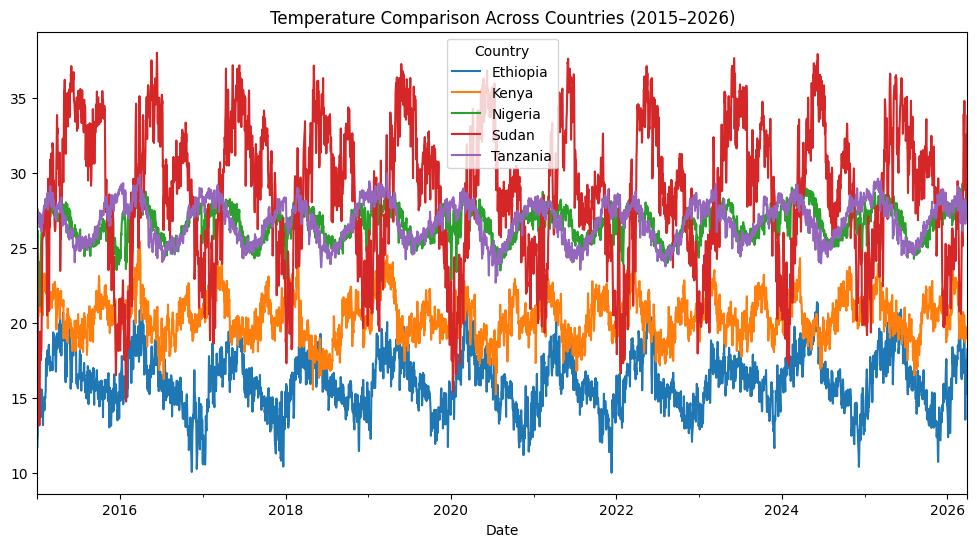

In [34]:
df_all.groupby(["Date", "Country"])["T2M"].mean().unstack().plot(figsize=(12,6))
plt.title("Temperature Comparison Across Countries (2015–2026)")
plt.show()

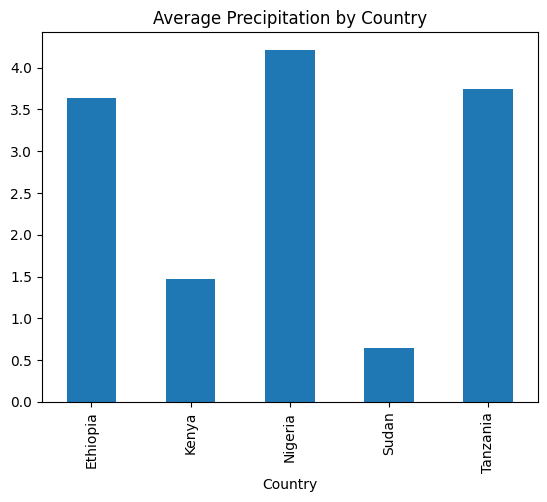

In [35]:
df_all.groupby("Country")["PRECTOTCORR"].mean().plot(kind="bar")
plt.title("Average Precipitation by Country")
plt.show()

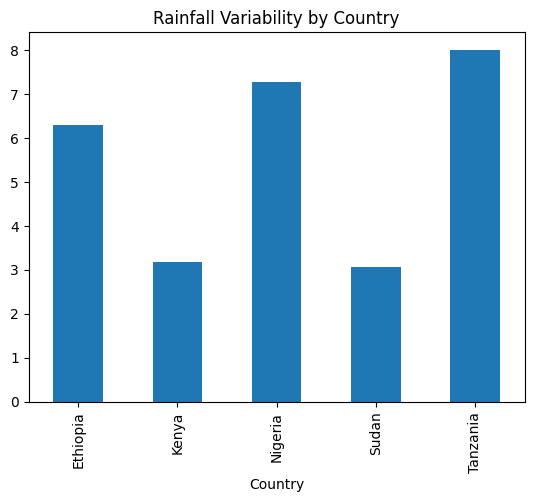

In [36]:
df_all.groupby("Country")["PRECTOTCORR"].std().plot(kind="bar")
plt.title("Rainfall Variability by Country")
plt.show()

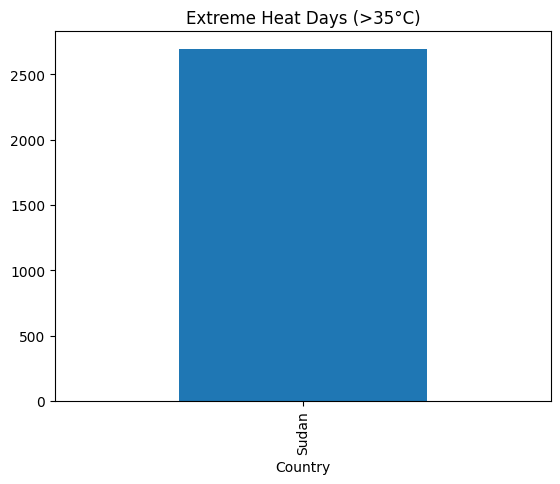

In [37]:
extreme_heat = df_all[df_all["T2M_MAX"] > 35].groupby("Country").size()
extreme_heat.plot(kind="bar")
plt.title("Extreme Heat Days (>35°C)")
plt.show()

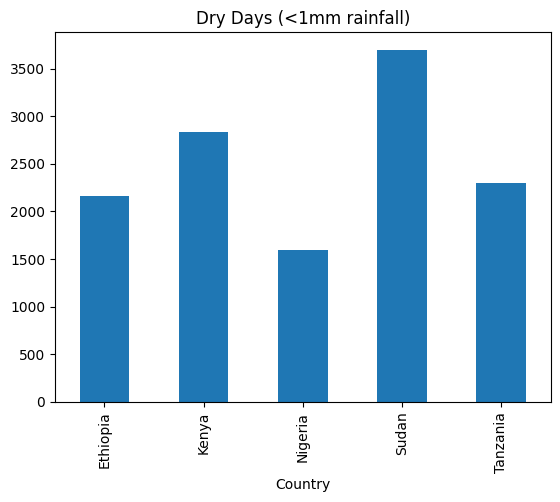

In [38]:
dry_days = df_all[df_all["PRECTOTCORR"] < 1].groupby("Country").size()
dry_days.plot(kind="bar")
plt.title("Dry Days (<1mm rainfall)")
plt.show()